In [1]:
# =============================================
# IMPORTY, ZAŘÍZENÍ, PROSTŘEDÍ
# =============================================
# Varianta A vyžaduje zmražený UniverSeg (veřejné váhy) — pokud není nainstalován:
#   pip install git+https://github.com/JJGO/UniverSeg.git
#   pip install scipy nibabel
# Data se stahují automaticky do /tmp (WBC z githubu, OASIS z surfer.nmr.mgh.harvard.edu).
import os
import sys
import pathlib
import subprocess
import warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

warnings.filterwarnings('ignore')

# 3-cestná detekce kvůli Apple Silicon (viz CLAUDE.md)
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'✓ Device: {device}')
print(f'✓ PyTorch: {torch.__version__}')

# práce z kořene repozitáře (obrázky ukládáme do figures/)
_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
print(f'✓ Working directory: {os.getcwd()}')

DEVICE = device
IMG_SIZE = (128, 128)  # nativní vstup UniverSeg (ss64, nf64)
FIGDIR = os.path.join(os.getcwd(), 'figures', 'VariantA_universeg')
os.makedirs(FIGDIR, exist_ok=True)
DOMAIN_COLORS = {'WBC-JTSC': '#1f77b4', 'WBC-CV': '#ff7f0e', 'OASIS': '#d62728'}

✓ Device: mps
✓ PyTorch: 2.10.0
✓ Working directory: /Users/ruslanguliev/VU_RG


In [2]:
# =============================================
# DATA — domény se sjednoceným rozhraním Domain
# =============================================
# Každá doména vrací pool obrázků [N,1,H,W] (float32, [0,1]) a masek [N,1,H,W] ({0,1}).
# Split support/test je deterministický (seed 42): support pool = zdroj kontextu,
# test pool = query obrázky. Prior maska = E[y] přes pool masek.

@dataclass
class Domain:
    name: str
    images: torch.Tensor
    masks: torch.Tensor
    support_idx: np.ndarray
    test_idx: np.ndarray

    @property
    def n_support(self): return len(self.support_idx)
    @property
    def n_test(self): return len(self.test_idx)

    def prior_mask(self, pool='support'):
        """Operační prior maska E[y_ij] ≈ (1/M) Σ mask_m (A.5). Průměr přes SUPPORT pool
        (aby nebyla kontaminovaná query obrázky, proti nimž měříme d_prior)."""
        idx = self.support_idx if pool == 'support' else self.test_idx
        return self.masks[idx].mean(dim=0)

def _split_indexes(n, support_frac=0.7, seed=42):
    rng = np.random.default_rng(seed)
    p = rng.permutation(n)
    i = int(np.floor(support_frac * n))
    return p[:i], p[i:]

# ---- WBC (bílé krvinky); maska png: 0=pozadí, 128=cytoplazma, 255=jádro ----
_WBC_ROOT = pathlib.Path('/tmp/universeg_wbc')
_WBC_SUBDIR = {'JTSC': 'Dataset 1', 'CV': 'Dataset 2'}
_WBC_LABELVAL = {'background': 0, 'cytoplasm': 128, 'nucleus': 255}

def _require_wbc():
    if not _WBC_ROOT.exists():
        subprocess.run(['git', 'clone', 'https://github.com/zxaoyou/segmentation_WBC.git',
                        str(_WBC_ROOT)], stderr=subprocess.DEVNULL, check=True)
    return _WBC_ROOT

def load_wbc(dataset='JTSC', label='cell', seed=42):
    """WBC doména. label='cell' (cytoplazma∪jádro = nejčistší centrovaný blob, default)."""
    root = _require_wbc()
    path = root / _WBC_SUBDIR[dataset]
    imgs, masks = [], []
    for bmp in sorted(path.glob('*.bmp')):
        img = Image.open(bmp).resize(IMG_SIZE, Image.BILINEAR).convert('L')
        img = np.asarray(img, dtype=np.float32) / 255.0
        seg = np.asarray(Image.open(bmp.with_suffix('.png')).resize(IMG_SIZE, Image.NEAREST))
        m = (seg > 0).astype(np.float32) if label == 'cell' else (seg == _WBC_LABELVAL[label]).astype(np.float32)
        imgs.append(img); masks.append(m)
    images = torch.from_numpy(np.stack(imgs))[:, None]
    masks_t = torch.from_numpy(np.stack(masks))[:, None]
    sup, tst = _split_indexes(len(imgs), seed=seed)
    return Domain(f'WBC-{dataset}', images, masks_t, sup, tst)

# ---- OASIS (mozková MRI); slice_seg4: 1=kůra,2=subkort,3=bílá hmota,4=CSF ----
_OASIS_ROOT = pathlib.Path('/tmp/universeg_oasis')

def _require_oasis():
    if not any(_OASIS_ROOT.glob('OASIS_OAS1_*_MR1')):
        tar = _OASIS_ROOT / 'neurite-oasis.2d.v1.0.tar'
        subprocess.run(['curl', '-sL', 'https://surfer.nmr.mgh.harvard.edu/ftp/data/neurite/data/neurite-oasis.2d.v1.0.tar',
                        '--create-dirs', '-o', str(tar)], check=True)
        subprocess.run(['tar', 'xf', str(tar), '-C', str(_OASIS_ROOT)], check=True)
    return _OASIS_ROOT

def load_oasis(label=3, max_subjects=414, seed=42):
    """OASIS doména (silná OOD vůči WBC). label=3 = bílá hmota (velká centrální struktura)."""
    import nibabel as nib
    _require_oasis()
    dirs = sorted(_OASIS_ROOT.glob('OASIS_OAS1_*_MR1'))[:max_subjects]
    imgs, masks = [], []
    for d in dirs:
        nrm, seg = d / 'slice_norm.nii.gz', d / 'slice_seg4.nii.gz'
        if not (nrm.exists() and seg.exists()):
            continue
        img = (nib.load(nrm).get_fdata() * 255).astype(np.uint8).squeeze()
        img = Image.fromarray(img).resize(IMG_SIZE, Image.BILINEAR).convert('L')
        img = np.rot90(np.asarray(img, dtype=np.float32) / 255.0, -1).copy()
        s = nib.load(seg).get_fdata().astype(np.int16).squeeze()
        s = np.asarray(Image.fromarray(s.astype(np.int32)).resize(IMG_SIZE, Image.NEAREST))
        s = np.rot90(s, -1).copy()
        imgs.append(img); masks.append((s == label).astype(np.float32))
    images = torch.from_numpy(np.stack(imgs))[:, None]
    masks_t = torch.from_numpy(np.stack(masks))[:, None]
    sup, tst = _split_indexes(len(imgs), seed=seed)
    return Domain('OASIS', images, masks_t, sup, tst)

print('✓ Data loadery připraveny (load_wbc, load_oasis)')

✓ Data loadery připraveny (load_wbc, load_oasis)


In [3]:
# =============================================
# MODEL (zmražený UniverSeg, K=1) + METRIKY
# =============================================

def load_universeg():
    """Předtrénovaný UniverSeg, zmražený, eval. Voláme jej na JEDNOM support setu (K=1),
    tj. bez nativního ensemblingu přes K náhodných tahů."""
    from universeg import universeg
    model = universeg(pretrained=True).to(DEVICE).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model

def _mps_gc():
    """Uvolní MPS cache + synchronizuje. NUTNÉ po každém batchi: jinak se na MPS po mnoha
    forward passech hromadí paměťový tlak, který TIŠE korumpuje výstup (Dice→0)."""
    if DEVICE == 'mps':
        torch.mps.empty_cache(); torch.mps.synchronize()

@torch.no_grad()
def predict(model, query_img, sup_img, sup_mask):
    """Jeden forward pass (K=1). Vrací p̂ ∈ [0,1], tvar [B,1,H,W]."""
    logits = model(query_img.to(DEVICE), sup_img.to(DEVICE), sup_mask.to(DEVICE))
    out = torch.sigmoid(logits).cpu()
    _mps_gc()
    return out

_EPS = 1e-6
def soft_mse(a, b):  # per-pixel Brier
    return float(((a - b) ** 2).mean())

def sym_kl(p, q):    # symetrická KL dvou měkkých map
    p = p.clamp(_EPS, 1 - _EPS); q = q.clamp(_EPS, 1 - _EPS)
    kl = lambda a, b: a * (a / b).log() + (1 - a) * ((1 - a) / (1 - b)).log()
    return float((0.5 * (kl(p, q) + kl(q, p))).mean())

def dice(pred_hard, gt):
    inter = (pred_hard * gt).sum(); denom = pred_hard.sum() + gt.sum()
    return float((2 * inter + _EPS) / (denom + _EPS))

def boundary_band(gt, width=3):
    """Hraniční pásmo = dilatace − eroze GT (A.5 ii). Ambiguita žije na hranici."""
    g = gt.squeeze().cpu().numpy() > 0.5
    st = ndimage.generate_binary_structure(2, 1)
    return torch.from_numpy(ndimage.binary_dilation(g, st, width) & ~ndimage.binary_erosion(g, st, width))

def reliability_and_ece(p, y, n_bins=15):
    """Reliability diagram + ECE. bin_acc = empir. frekvence foreground; kalibrovaný ≈ bin_center."""
    p = p.ravel(); y = y.ravel().astype(np.float64)
    edges = np.linspace(0, 1, n_bins + 1); centers = 0.5 * (edges[:-1] + edges[1:])
    conf = np.full(n_bins, np.nan); acc = np.full(n_bins, np.nan); ece = 0.0; N = len(p)
    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]
        m = (p >= lo) & (p < hi) if b < n_bins - 1 else (p >= lo) & (p <= hi)
        if m.sum() == 0:
            continue
        conf[b] = p[m].mean(); acc[b] = y[m].mean(); ece += (m.sum() / N) * abs(acc[b] - conf[b])
    return centers, conf, acc, ece

def signed_calibration_gap(p, y):
    """Průměr (confidence − accuracy), confidence=max(p,1-p). >0 over-, <0 under-confident."""
    p = p.ravel(); y = y.ravel()
    conf = np.maximum(p, 1 - p)
    correct = ((p >= 0.5).astype(np.float64) == y).astype(np.float64)
    return float((conf - correct).mean())

print('✓ Model loader + metriky připraveny')

✓ Model loader + metriky připraveny


In [4]:
# =============================================
# RUNNER kříže (n_supp × doména) + figury
# =============================================

@dataclass
class CellResult:
    domain: str
    n_supp: int
    d_truth_mse: List[float] = field(default_factory=list)
    d_prior_mse: List[float] = field(default_factory=list)
    d_prior_symkl: List[float] = field(default_factory=list)
    dice: List[float] = field(default_factory=list)
    ece_all: List[float] = field(default_factory=list)
    ece_boundary: List[float] = field(default_factory=list)
    ece_interior: List[float] = field(default_factory=list)
    calib_gap: List[float] = field(default_factory=list)
    _rel_p: List[np.ndarray] = field(default_factory=list)
    _rel_y: List[np.ndarray] = field(default_factory=list)
    seeds: List[int] = field(default_factory=list)

    def summary(self):
        def ms(x):
            a = np.asarray(x, float)
            return (float(a.mean()), float(a.std(ddof=1) / np.sqrt(len(a)))) if len(a) else (np.nan, np.nan)
        out = {'domain': self.domain, 'n_supp': self.n_supp, 'n_obs': len(self.d_truth_mse)}
        for k in ['d_truth_mse','d_prior_mse','d_prior_symkl','dice','ece_all','ece_boundary','ece_interior','calib_gap']:
            m, e = ms(getattr(self, k)); out[k + '_mean'] = m; out[k + '_sem'] = e
        return out

    def reliability(self, n_bins=15):
        if not self._rel_p:
            return None
        return reliability_and_ece(np.concatenate(self._rel_p), np.concatenate(self._rel_y), n_bins)

def run_cell(model, domain, n_supp, *, n_query=60, n_draws=3, base_seed=0,
             prior_mask=None, boundary_width=3, n_bins=15, batch=16, pair_budget=128, verbose=True):
    """Jedna buňka designu (doména × n_supp): přes n_draws tahů support setu a n_query
    query obrázků měří d_truth, d_prior, Dice, kalibraci. Reportuje surové per-query hodnoty."""
    if prior_mask is None:
        prior_mask = domain.prior_mask('support')
    res = CellResult(domain.name, n_supp)
    q_all = domain.test_idx
    n_query = min(n_query, len(q_all))
    # paměť CrossBlocku roste s batch×n_supp → držíme součin pod pair_budget (jinak MPS OOM)
    eff_batch = max(1, min(batch, pair_budget // n_supp))
    for d in range(n_draws):
        seed = base_seed + 1000 * n_supp + d
        res.seeds.append(seed)
        rng = np.random.default_rng(seed)
        sup_idx = rng.choice(domain.support_idx, n_supp, replace=False)
        sup_img = domain.images[sup_idx][None]; sup_mask = domain.masks[sup_idx][None]
        q_sel = rng.choice(q_all, n_query, replace=False)
        for start in range(0, n_query, eff_batch):
            qb = q_sel[start:start + eff_batch]
            qx = domain.images[qb]; gt = domain.masks[qb]; B = len(qb)
            p = predict(model, qx, sup_img.expand(B, -1, -1, -1, -1), sup_mask.expand(B, -1, -1, -1, -1))
            for j in range(B):
                pj, gj = p[j], gt[j]
                res.d_truth_mse.append(soft_mse(pj, gj))
                res.d_prior_mse.append(soft_mse(pj, prior_mask))
                res.d_prior_symkl.append(sym_kl(pj, prior_mask))
                res.dice.append(dice((pj >= 0.5).float(), gj))
                res.calib_gap.append(signed_calibration_gap(pj.numpy(), gj.numpy()))
                pn, yn = pj.squeeze().numpy(), gj.squeeze().numpy()
                res._rel_p.append(pn.ravel()); res._rel_y.append(yn.ravel())
                res.ece_all.append(reliability_and_ece(pn, yn, n_bins)[3])
                band = boundary_band(gj, boundary_width).numpy()
                if band.sum() > 0:
                    res.ece_boundary.append(reliability_and_ece(pn[band], yn[band], n_bins)[3])
                if (~band).sum() > 0:
                    res.ece_interior.append(reliability_and_ece(pn[~band], yn[~band], n_bins)[3])
        if verbose:
            print(f'  [{domain.name} n_supp={n_supp}] draw {d+1}/{n_draws} seed={seed} done', flush=True)
    return res

def run_grid(model, domains, n_supp_list, **kw):
    """Celý kříž designu. Osy drží ODDĚLENĚ (A.4): pro každou doménu celý n_supp sweep."""
    results = {}
    for dom in domains:
        prior = dom.prior_mask('support')
        for n in n_supp_list:
            print(f'[grid] domain={dom.name} n_supp={n}', flush=True)
            results[(dom.name, n)] = run_cell(model, dom, n, prior_mask=prior, **kw)
    return results

# ---- figury (ukládají do FIGDIR i zobrazují inline) ----
def _domains_sorted(summ):
    return sorted({s['domain'] for s in summ}, key=lambda d: list(DOMAIN_COLORS).index(d))

def fig_collapse_crossover(summ, n_supp_list, fname='fig_A_01_collapse_crossover.png'):
    domains = _domains_sorted(summ)
    fig, axes = plt.subplots(1, len(domains), figsize=(5*len(domains), 4.2), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, dom in zip(axes, domains):
        rows = sorted([s for s in summ if s['domain'] == dom], key=lambda s: s['n_supp'])
        n = [r['n_supp'] for r in rows]
        ax.errorbar(n, [r['d_truth_mse_mean'] for r in rows], yerr=[r['d_truth_mse_sem'] for r in rows],
                    marker='o', color='#2ca02c', label=r'$d_{\mathrm{truth}}$ (k pravdě)')
        ax.errorbar(n, [r['d_prior_mse_mean'] for r in rows], yerr=[r['d_prior_mse_sem'] for r in rows],
                    marker='s', color='#9467bd', label=r'$d_{\mathrm{prior}}$ (k prior masce)')
        ax.set_xscale('log', base=2); ax.set_xticks(n_supp_list); ax.set_xticklabels(n_supp_list)
        ax.set_xlabel(r'velikost support setu $n_{\mathrm{supp}}$'); ax.set_title(dom); ax.grid(alpha=0.3)
    axes[0].set_ylabel('soft MSE (per-pixel Brier)'); axes[0].legend(fontsize=9)
    fig.suptitle('Kolaps k prioru: crossover $d_{truth}\\!\\uparrow$, $d_{prior}\\!\\downarrow$ při ubývání kontextu', y=1.02)
    fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, fname), dpi=150, bbox_inches='tight'); plt.show()

def fig_dice(summ, n_supp_list, fname='fig_A_02_dice.png'):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    for dom in _domains_sorted(summ):
        rows = sorted([s for s in summ if s['domain'] == dom], key=lambda s: s['n_supp'])
        ax.errorbar([r['n_supp'] for r in rows], [r['dice_mean'] for r in rows],
                    yerr=[r['dice_sem'] for r in rows], marker='o', color=DOMAIN_COLORS[dom], label=dom)
    ax.set_xscale('log', base=2); ax.set_xticks(n_supp_list); ax.set_xticklabels(n_supp_list)
    ax.set_xlabel(r'$n_{\mathrm{supp}}$'); ax.set_ylabel('Dice (tvrdá maska, práh 0,5)')
    ax.set_title('Výkon vs velikost support setu (a OOD-ness)'); ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, fname), dpi=150, bbox_inches='tight'); plt.show()

def fig_reliability(rel, domains, n_show, fname='fig_A_03_reliability.png'):
    fig, axes = plt.subplots(len(domains), len(n_show), figsize=(3*len(n_show), 3*len(domains)), squeeze=False)
    for i, dom in enumerate(domains):
        for j, n in enumerate(n_show):
            ax = axes[i][j]; ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)
            data = rel.get((dom, n))
            if data is not None:
                centers, conf, acc, ece = data; ok = ~np.isnan(acc)
                ax.plot(conf[ok], acc[ok], marker='o', ms=4, color=DOMAIN_COLORS[dom])
                ax.text(0.05, 0.9, f'ECE={ece:.3f}', transform=ax.transAxes, fontsize=9)
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            if i == 0: ax.set_title(f'$n_{{supp}}$={n}')
            if j == 0: ax.set_ylabel(f'{dom}\nempir. frekvence')
            if i == len(domains) - 1: ax.set_xlabel('predikované p̂')
    fig.suptitle('Reliability diagramy (nad úhlopříčkou = under-confident, pod = over-confident)', y=1.01)
    fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, fname), dpi=150, bbox_inches='tight'); plt.show()

def fig_calibration(summ, n_supp_list, fname='fig_A_04_calibration.png'):
    domains = _domains_sorted(summ)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
    for dom in domains:
        rows = sorted([s for s in summ if s['domain'] == dom], key=lambda s: s['n_supp'])
        n = [r['n_supp'] for r in rows]; c = DOMAIN_COLORS[dom]
        axes[0].plot(n, [r['ece_all_mean'] for r in rows], marker='o', color=c, label=f'{dom} celek')
        axes[0].plot(n, [r['ece_boundary_mean'] for r in rows], marker='^', ls='--', color=c, label=f'{dom} hranice')
        axes[1].errorbar(n, [r['calib_gap_mean'] for r in rows], yerr=[r['calib_gap_sem'] for r in rows],
                         marker='s', color=c, label=dom)
    for ax in axes:
        ax.set_xscale('log', base=2); ax.set_xticks(n_supp_list); ax.set_xticklabels(n_supp_list)
        ax.set_xlabel(r'$n_{\mathrm{supp}}$'); ax.grid(alpha=0.3)
    axes[0].set_ylabel('ECE'); axes[0].set_title('Kalibrační chyba: celek vs hraniční pásmo'); axes[0].legend(fontsize=8)
    axes[1].axhline(0, color='k', lw=0.8); axes[1].set_ylabel('signed gap  (>0 over-, <0 under-confident)')
    axes[1].set_title('Směr kalibrace — MĚŘENÝ, ne předpokládaný'); axes[1].legend(fontsize=9)
    fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, fname), dpi=150, bbox_inches='tight'); plt.show()

def fig_prior_masks(domains, fname='fig_A_05_prior_masks.png'):
    fig, axes = plt.subplots(1, len(domains), figsize=(4*len(domains), 4), squeeze=False)
    for ax, dom in zip(axes[0], domains):
        pm = dom.prior_mask('support').squeeze().numpy()
        im = ax.imshow(pm, cmap='magma', vmin=0, vmax=1)
        ax.set_title(f'{dom.name}\nprior E[y], fg={pm.mean():.3f}'); ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle('Operační prior masky (marginální foreground přes support pool)', y=1.03)
    fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, fname), dpi=150, bbox_inches='tight'); plt.show()

print('✓ Runner + figury připraveny')

✓ Runner + figury připraveny


## Experiment A: Diagnostika kolapsu k prioru na zmraženém in-context segmenteru (UniverSeg)

### Motivace

V sériích GP1/GP2 jsme zkoumali PFN jako amortizovaný aproximátor GP inference ve **skalární
regresi**. Tento experiment zvedá stejnou diagnostiku — **bias (kolaps k prioru)** a
**kalibraci** — do **2D binární segmentace obrázků**. Mapování pojmů:

| GP2 (regrese) | Segmentace (Varianta A) |
|---|---|
| target $y \in \mathbb{R}$ | maska $y \in \{0,1\}^{H\times W}$ (per-pixel label) |
| PPD = Gaussovská hustota | per-pixel $p(y_{ij}=1)$ = Bernoulli $\hat{p}_{ij}\in[0,1]$ |
| support/kontext $D=\{(x_i,y_i)\}$ | support set $S=\{(\text{obrázek}_k,\text{maska}_k)\}$ |
| bias k prioru daleko od dat | posun predikce k marginální (prior) masce |

**Klíčová myšlenka.** [UniverSeg](https://github.com/JJGO/UniverSeg) je amortizovaný in-context
segmenter: podmíní se na support set dvojic (obrázek, maska) a jedním dopředným průchodem
segmentuje query obrázek, bez retrénování. To je **strukturálně tatáž myšlenka jako PFN**
(amortizuj přes úlohy, inferuj z kontextu), i když UniverSeg *není* PFN — trénuje se
supervizovaně na MegaMedical, ne KL kritériem na syntetických tazích z explicitního prioru.

Naglerova teorie (Thm 5.4, *locality condition*) tvrdí, že jakýkoli amortizovaný prediktor
s **globální** (softmax-like) attention má neredukovatelný bias: daleko od dat se predikce
vrací k prioru. UniverSeg váhuje support přes CrossBlock (feature-averaging s globálním
dosahem), takže by měl tento bias **zdědit**, protože sdílí architektonickou příčinu. Pokud
se to potvrdí, jev **není** artefakt PFN trénovací procedury, ale vlastnost amortizace obecně
— silnější tvrzení, než jaké lze prokázat na jednom vlastním PFN.

### Co měříme (striktně odděleně)

1. **Kolaps k prioru (bias):** posouvá se predikovaná maska k marginální prior masce, když se
   support set zmenšuje nebo posouvá do OOD? Podpis = **crossover** $d_{truth}\uparrow$,
   $d_{prior}\downarrow$.
2. **Kalibrace:** směr over-/under-confidence **měříme, nepředpokládáme** (návod výslovně
   varuje před univerzáliemi).

### Design — dvě ortogonální osy degradace (A.4)

- **Osa 1 — velikost support setu** $n_{\text{supp}}\in\{1,2,4,8,16,32,64\}$.
- **Osa 2 — OOD-ness domény:** WBC-JTSC (kotva/ID) $\to$ WBC-CV (mírné OOD, jiná akvizice)
  $\to$ OASIS (silné OOD, jiná modalita i anatomie).

Model je **zmražený, K=1** (nativní ensembling přes support sety vypnut). Statistika: 60 query
obrázků × 3 tahy support setu na buňku, error bary z per-query hodnot, logované seedy.

## Krok 1 — Načtení modelu a domén

Načteme zmražený UniverSeg a tři domény v pořadí rostoucí OOD-ness. U každé vypíšeme velikost
support/test poolu a **foreground frakci prior masky** — ta je smysluplná jen na prostorově
zarovnaných datech (WBC = centrovaná buňka; OASIS = roughly-registered bílá hmota).

In [5]:
model = load_universeg()
domains = [
    load_wbc('JTSC', 'cell'),   # kotva / ID
    load_wbc('CV', 'cell'),     # mírné OOD (jiná akvizice)
    load_oasis(max_subjects=414),  # silné OOD (mozková MRI, bílá hmota)
]
dom_names = [d.name for d in domains]
for d in domains:
    print(f'{d.name:10s}: support={d.n_support:>3} test={d.n_test:>3} '
          f'prior_fg={float(d.prior_mask("support").mean()):.3f}')
print('Domény (rostoucí OOD-ness):', dom_names)

WBC-JTSC  : support=210 test= 90 prior_fg=0.315
WBC-CV    : support= 70 test= 30 prior_fg=0.226
OASIS     : support=289 test=125 prior_fg=0.187
Domény (rostoucí OOD-ness): ['WBC-JTSC', 'WBC-CV', 'OASIS']


## Krok 2 — SPUŠTĚNÍ celého kříže (n_supp × doména)

Toto je jediný výpočetně náročný krok: pro každou doménu projedeme celý sweep $n_{\text{supp}}$
(osy držíme oddělené, A.4). Trvá řádově minuty. Výsledkem je slovník `results` a agregace
`summ` (souhrny s SEM) a `rel` (reliability křivky), z nichž pak kreslíme všechny obrázky.

In [6]:
N_SUPP = [1, 2, 4, 8, 16, 32, 64]
results = run_grid(model, domains, N_SUPP, n_query=60, n_draws=3, base_seed=0)
summ = [results[k].summary() for k in results]
rel = {k: results[k].reliability() for k in results}
print('\n✓ Hotovo. Buněk:', len(results), '| pozorování/buňka (JTSC n=1):', summ[0]['n_obs'])

[grid] domain=WBC-JTSC n_supp=1


  [WBC-JTSC n_supp=1] draw 1/3 seed=1000 done


  [WBC-JTSC n_supp=1] draw 2/3 seed=1001 done


  [WBC-JTSC n_supp=1] draw 3/3 seed=1002 done


[grid] domain=WBC-JTSC n_supp=2


...

[grid] domain=OASIS n_supp=64


  [OASIS n_supp=64] draw 1/3 seed=64000 done


  [OASIS n_supp=64] draw 2/3 seed=64001 done


  [OASIS n_supp=64] draw 3/3 seed=64002 done



✓ Hotovo. Buněk: 21 | pozorování/buňka (JTSC n=1): 180


## (1) Kolaps k prioru — crossover $d_{truth}$ × $d_{prior}$

Pro každou doménu vykreslíme dvě vzdálenosti jako funkci $n_{\text{supp}}$:
- $d_{truth}$ = per-pixel soft MSE (Brier) mezi predikcí $\hat{p}$ a ground-truth maskou,
- $d_{prior}$ = tatáž vzdálenost mezi $\hat{p}$ a **operační prior maskou** $E[y]$.

**Podpis kolapsu** = crossover: jak data ubývají, $d_{truth}$ roste a predikce se přimyká
k prior masce.

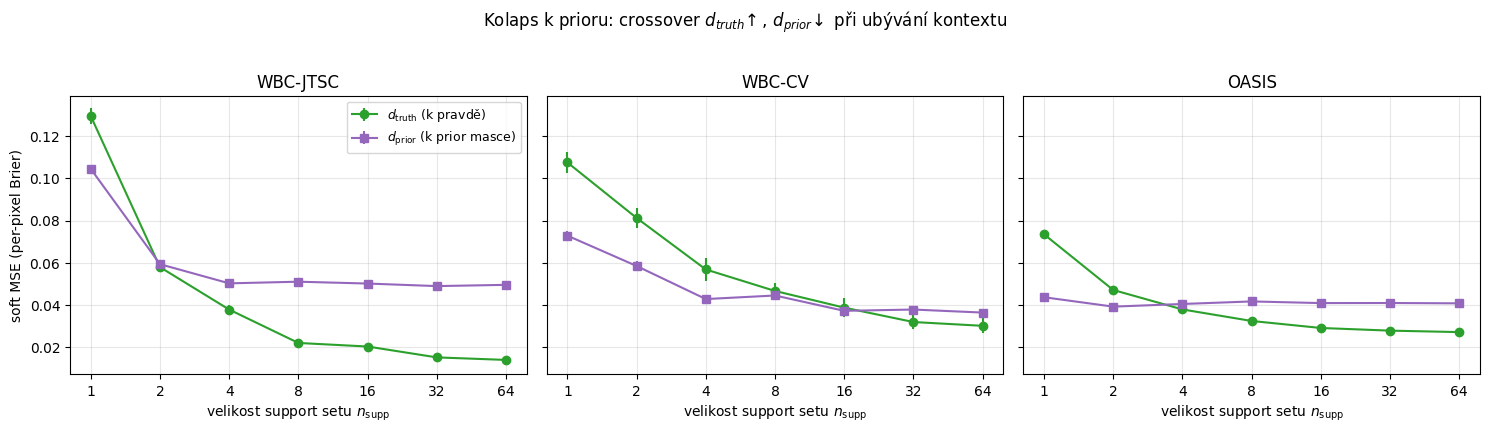

In [7]:
fig_collapse_crossover(summ, N_SUPP)

### Jak číst výstup (1)

U všech tří domén je při $n_{\text{supp}}=1$ predikce **blíž prior masce než pravdě**
($d_{prior} < d_{truth}$) — to je přesně bias člen $E[q(y\mid x,D)] - p_0(y\mid x)$ v režimu
neinformativních dat. Jak $n_{\text{supp}}$ roste, $d_{truth}$ se propadá pod $d_{prior}$
(crossover kolem $n\approx2$ u JTSC, $n\approx8\text{–}16$ u CV, $n\approx4$ u OASIS) a predikce
se od defaultní masky vzdálí a přilne k pravdě.

Důležité: $d_{prior}$ **nekonverguje k nule** — silný model při dostatku kontextu vydává
predikci specifickou pro daný query, ne marginální průměr. To je rozdíl oproti triviálnímu
kernel-averagingu, který by k prior masce konvergoval. Kolaps se projevuje **jen** při
degradaci vstupu, přesně jak předpovídá locality condition.

## (2) Výkon (Dice) — saturace kontextem

Dice na tvrdých maskách (práh 0,5) je čitelný proxy výkonu. Sledujeme, jak roste s
$n_{\text{supp}}$ a jak ho sráží OOD-ness domény.

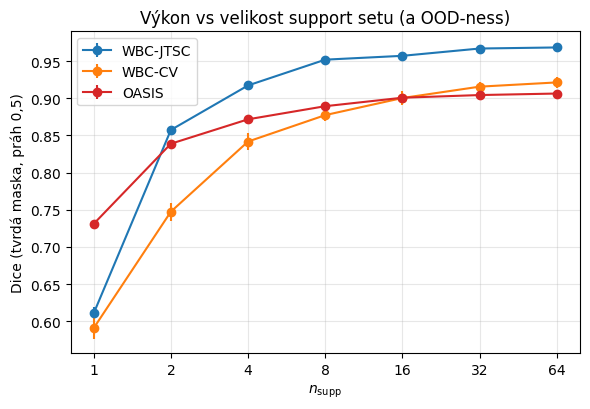

In [8]:
fig_dice(summ, N_SUPP)

### Jak číst výstup (2)

Dice roste a **saturuje** (plató od $n_{\text{supp}}\approx8\text{–}16$). To je přímý 2D analog
Experimentu 5 z GP2 (context size → error saturace) a plató popsaného v původním UniverSeg
článku. OOD-ness plató sráží: WBC-JTSC ($\approx0{,}97$) > WBC-CV ($\approx0{,}92$). OASIS má
vyšší Dice při $n=1$ díky velké, konzistentně umístěné struktuře (bílá hmota), ale plató je
nejnižší — silné OOD.

## (3) Kalibrace I — reliability diagramy

Pro vybrané $n_{\text{supp}}$ a každou doménu vykreslíme reliability diagram: empirickou
frekvenci foreground vs predikované $\hat{p}$. Body **nad** úhlopříčkou znamenají
under-confidence (model podstřeluje $\hat{p}$), **pod** úhlopříčkou over-confidence.

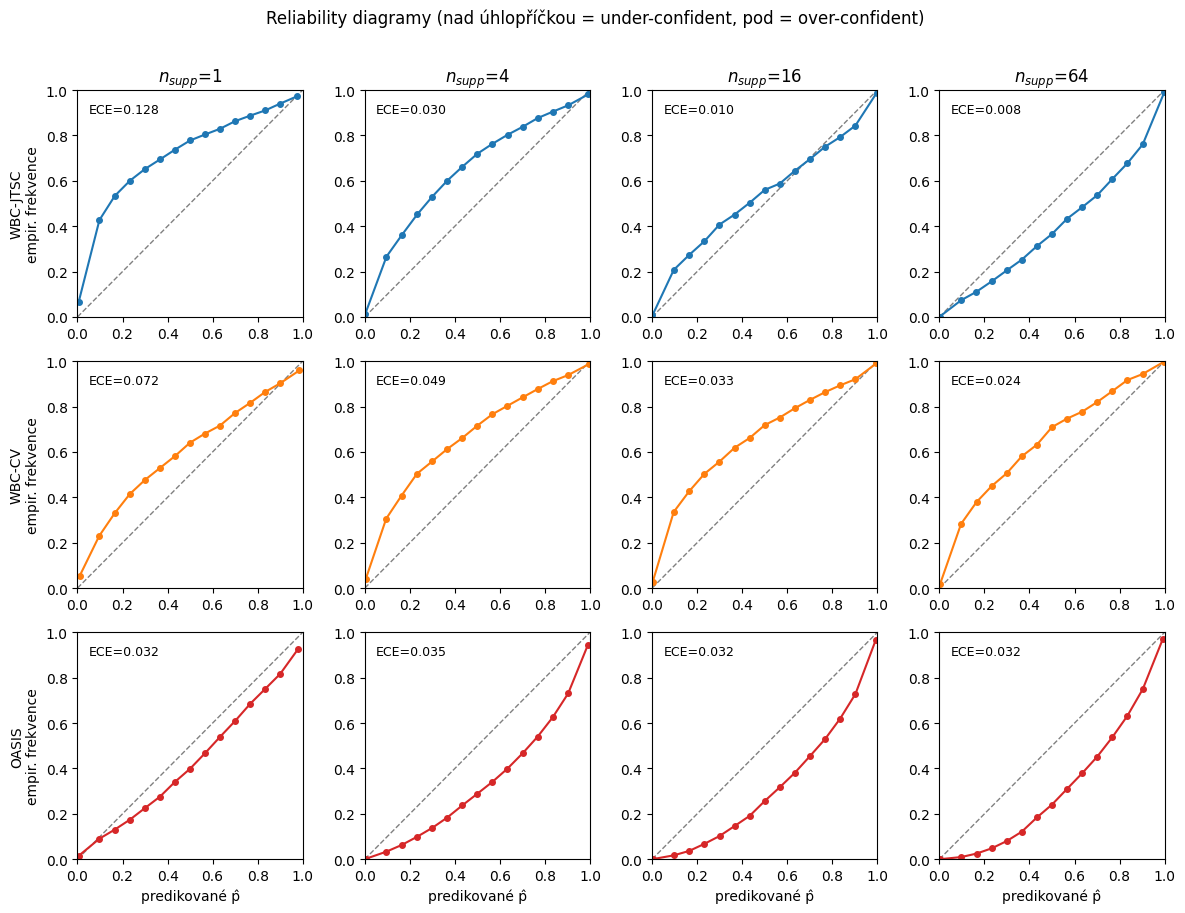

In [9]:
fig_reliability(rel, dom_names, [1, 4, 16, 64])

### Jak číst výstup (3)

Směr kalibrace je **doménově závislý** — přesně proto návod trval na tom, aby se **měřil**, ne
předpokládal:
- **WBC (JTSC i CV): under-confident** — křivky nad úhlopříčkou; model podstřeluje
  pravděpodobnost foreground. S rostoucím $n_{\text{supp}}$ se JTSC blíží úhlopříčce (ECE
  $0{,}13 \to 0{,}01$).
- **OASIS: over-confident** — křivky pod úhlopříčkou, prakticky nezávisle na $n_{\text{supp}}$
  (ECE $\approx0{,}03$ konstantní).

Tvrzení „variance je univerzálně podstřelená" by tedy bylo chybné — kalibrace in-context
segmenteru je nestabilní a závisí na doméně.

## (4) Kalibrace II — ECE (hranice vs vnitřek) a směr

Rozložíme kalibraci: (vlevo) ECE počítaná zvlášť pro **celou masku** a pro **hraniční pásmo**
(dilatace−eroze GT) — ambiguita žije na hranici; (vpravo) znaménkový calibration gap
(confidence − accuracy) jako skalární shrnutí směru.

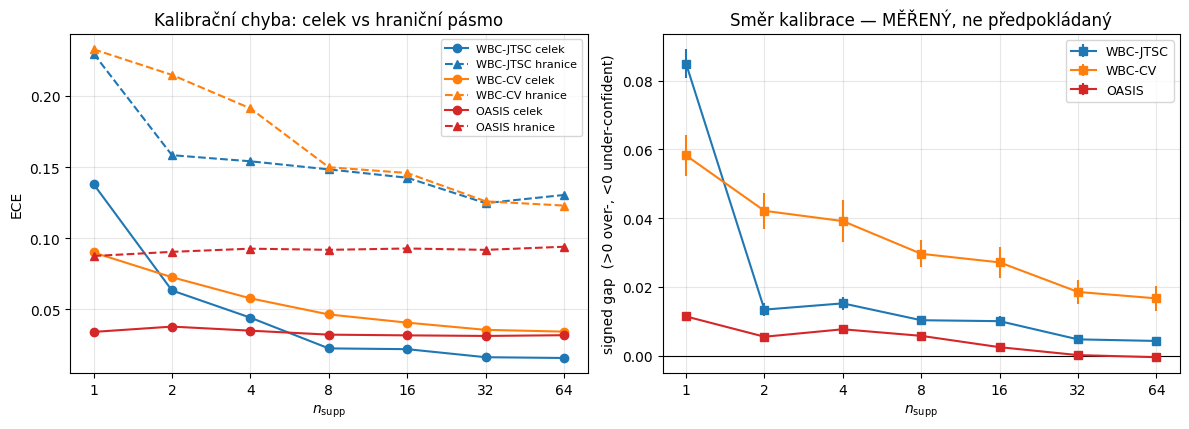

In [10]:
fig_calibration(summ, N_SUPP)

### Jak číst výstup (4)

**Hraniční pásmo je výrazně hůř kalibrované** než vnitřek objektu (ECE na hranici řádově vyšší)
a s $n_{\text{supp}}$ klesá pomaleji — u OASIS je hraniční ECE přes celý sweep prakticky
konstantní. Nejistota na hranici struktury je tedy **neredukovatelná** ani velkým kontextem,
kdežto vnitřek se plně vyřeší. To odpovídá pozorování, že průměr přes celou masku ambiguitu na
hranici rozmělní (A.5 ii).

Znaménkový gap (confidence = $\max(\hat{p},1-\hat{p})$, smysl „mám-li pravdu") je kladný všude,
nejsilněji při $n_{\text{supp}}=1$, a s kontextem klesá k nule. Nejde o rozpor s reliability
diagramem — obě metriky měří jiný pojem (frekvence foreground vs. správnost tvrdého
rozhodnutí). Souhrnně: kalibrace se **zlepšuje** s kontextem, ale směr a míra závisí na doméně.

## (5) Operační prior masky — obhajoba metriky (i)

Metrika kolapsu (i) stojí a padá s definicí „prior masky". Vykreslíme ji: marginální foreground
$E[y]$ přes support pool každé domény.

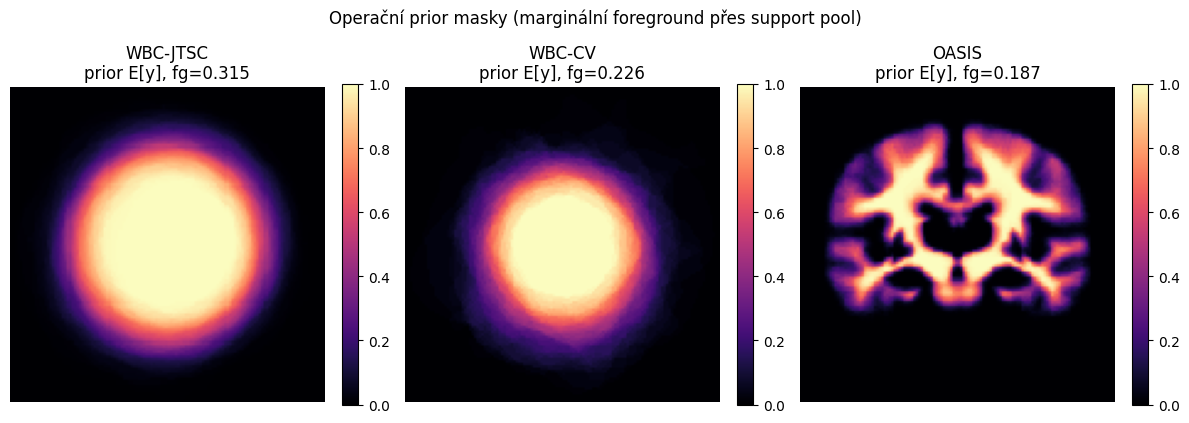

In [11]:
fig_prior_masks(domains)

### Jak číst výstup (5)

WBC (JTSC i CV) dává **čistý centrovaný blob** — buňka je kompaktní a přibližně zarovnaná, takže
průměrná maska je smysluplná „defaultní" predikce (foreground $\approx0{,}3$ / $0{,}23$). OASIS
bílá hmota ukazuje charakteristickou motýlkovou strukturu — roughly-registered, strukturovanější,
ale i mírně zašuměnější signál. To potvrzuje, že metrika (i) je legitimní jen na **prostorově
zarovnaných** datech (past A.7); u nezarovnaných domén by prior maska ztratila význam.

---

# Kompletní výkladová část: Co jsme zjistili a co to znamená

Tato závěrečná sekce shrnuje experiment i pro čtenáře bez pozadí v amortizované inferenci a
propojuje výsledky s teorií i s navazující Variantou C.

## O čem tento notebook je

Chtěli jsme vědět, zda **patologie, které PFN teorie předpovídá pro amortizovanou inferenci**,
existují i na *hotovém, reálném* in-context segmenteru — a to bez trénování čehokoli. Vzali jsme
zmražený UniverSeg a systematicky mu **zhoršovali vstup** ve dvou nezávislých směrech: ubírali
kontext (support set) a posouvali doménu mimo to, co model zná. Sledovali jsme dvě věci: zda se
predikce **hroutí k prioru** (bias) a jak se chová **kalibrace** (jistota).

## Tři hlavní zjištění

1. **Kolaps k prioru existuje i na ne-PFN modelu (bias term).** Při jednom support obrázku je
   predikce blíž průměrné (prior) masce než pravdě; s přibývajícím kontextem se od prioru odpoutá
   a přilne k pravdě (crossover $d_{truth}\uparrow$, $d_{prior}\downarrow$). Protože UniverSeg
   *není* PFN, je tento jev vlastností **amortizace / globální attention**, ne konkrétní
   trénovací procedury — přesně jak předpovídá Naglerova locality condition. To je silnější
   tvrzení, než jaké lze prokázat na jednom vlastním PFN.

2. **Výkon saturuje s kontextem (2D analog Exp. 5 z GP2).** Dice roste a od
   $n_{\text{supp}}\approx8\text{–}16$ se láme do plató; OOD-ness plató snižuje. Stejná
   context-size saturace, jakou známe z PFN regrese, platí i pro 2D masky.

3. **Kalibrace je nestabilní a doménově závislá.** WBC je under-confident, OASIS over-confident
   (v reliability smyslu). Nejhůř kalibrované je **hraniční pásmo** objektu, a ta nejistota je
   na hranici z velké části neredukovatelná i velkým kontextem. Univerzální tvrzení o směru
   (např. „variance je vždy podstřelená") by bylo chybné — proto jsme směr měřili, ne
   předpokládali.

## Limity (a proč následuje Varianta C)

UniverSeg **nemá pravý prior** ani spočitatelný posterior — naše prior maska je jen *operační*
aproximace (průměrná maska) a funguje pouze na prostorově zarovnaných datech. Měříme tedy kolaps
proti heuristice, ne proti pravdě. Kalibraci jsme nerekalibrovali (případná rekalibrace =
temperature scaling na logitech, ne σ-scaling, protože jde o binární per-pixel Bernoulli).

Tuto slabinu odstraní **Varianta C**: postaví se skutečný PFN na *explicitním* GP prioru, kde je
pravý posterior spočitatelný **oraclem**, a amortizační bias se změří **proti pravdě** — přímé
pokračování GP2 (bias² + variance rozklad) do 2D binárního targetu.

## Souhrnné tvrzení

*In-context segmentery dědí prior-collapse předpovězený PFN teorií (crossover při ubývání
kontextu); kalibrace je nestabilní a doménově závislá a nejhorší na hranici objektu. Jev existuje
na reálném modelu → má smysl postavit kalibrovaný PFN (Varianta C) a měřit tytéž patologie proti
oraclu.*

**Reprodukovatelnost (pasti, na které jsme narazili).** MPS po mnoha forward passech / velkém
support setu **tiše korumpuje** výstup (Dice→0) a při velkém `batch × n_supp` padá na OOM —
řešeno `torch.mps.empty_cache()` + `synchronize()` po každém batchi a adaptivním
`eff_batch = min(batch, pair_budget // n_supp)`. Autoritativní čísla (průměry ± SEM) jsou v
[background/VariantA_experiments_article.md](../background/VariantA_experiments_article.md).